# Introduction

The objective of this task is to predict whether a customer will subscribe to a term deposit based on marketing campaign data.

We aim to:
- Explore customer data
- Encode categorical variables
- Train classification models
- Evaluate performance using metrics
- Explain predictions using SHAP

# Dataset Description

The dataset contains customer information such as:

- age
- job
- marital status
- education
- balance
- housing loan
- contact type

Target Variable:
- y (Yes/No subscription)

In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("bank.csv", sep=';')

# Display basic info
print(df.shape)
print(df.columns)

df.head()

(11162, 1)
Index(['age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit'], dtype='object')


,"age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit"
0,"59,admin.,married,secondary,no,2343,yes,no,unk..."
1,"56,admin.,married,secondary,no,45,no,no,unknow..."
2,"41,technician,married,secondary,no,1270,yes,no..."
3,"55,services,married,secondary,no,2476,yes,no,u..."
4,"54,admin.,married,tertiary,no,184,no,no,unknow..."


# Data Cleaning

- Checked for missing values
- Encoded categorical variables
- Prepared dataset for machine learning

In [ ]:
# Check missing values
print(df.isnull().sum())

age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit    0
dtype: int64


# Exploratory Data Analysis

We analyze customer demographics and subscription behavior.

In [ ]:
df.columns = df.columns.str.strip()
print(df.columns.tolist())

['age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit']


['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'deposit']


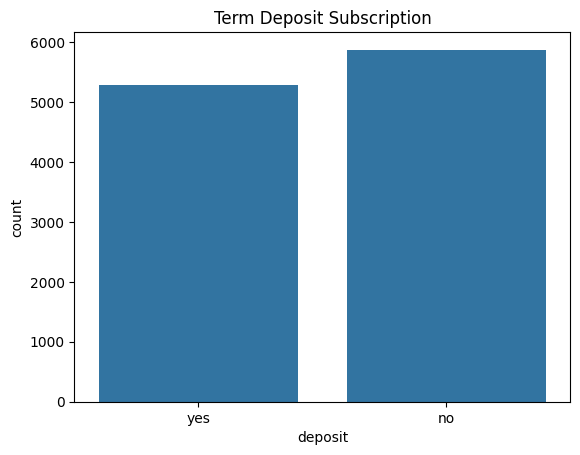

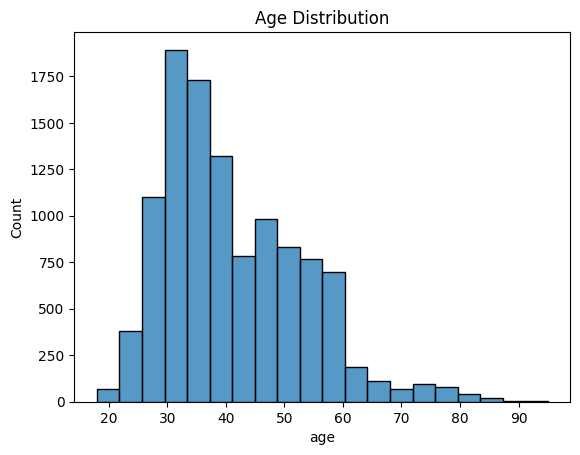

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset correctly
df = pd.read_csv("bank.csv")

# Clean column names
df.columns = df.columns.str.strip()

# Check columns
print(df.columns.tolist())

# Plot
sns.countplot(data=df, x='deposit')
plt.title("Term Deposit Subscription")
plt.show()

# Age distribution
sns.histplot(df['age'], bins=20)
plt.title("Age Distribution")
plt.show()

The visualizations show customer distribution and subscription patterns. Most customers did not subscribe to the term deposit.

# Feature Encoding

Categorical variables are converted into numerical format using Label Encoding.

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Encode categorical columns
le = LabelEncoder()

for col in df.select_dtypes(include='object'):
    df[col] = le.fit_transform(df[col])

# Model Training

We use Logistic Regression and Random Forest classifiers.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Features & target
X = df.drop('deposit', axis=1)
y = df['deposit']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

# Random Forest
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


RandomForestClassifier()

# Model Evaluation

We evaluate the models using:
- Accuracy
- Confusion Matrix
- F1 Score
- ROC Curve

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    roc_curve,
    auc
)

# Predictions
y_pred = rf.predict(X_test)

# Metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.8307210031347962
F1 Score: 0.8277119416590701
Confusion Matrix:
 [[947 219]
 [159 908]]


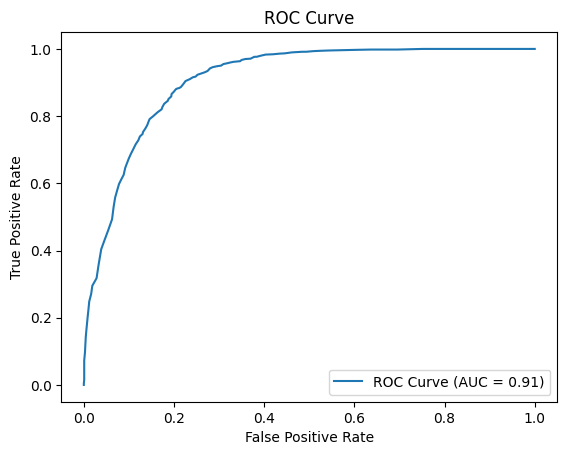

In [ ]:
# ROC Curve
y_prob = rf.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label='ROC Curve (AUC = %0.2f)' % roc_auc)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')

plt.legend()
plt.show()

# Explainable AI using SHAP

SHAP helps explain how features influence model predictions.

In [ ]:
!pip install shap

100%|===================| 4461/4466 [05:01<00:00]       

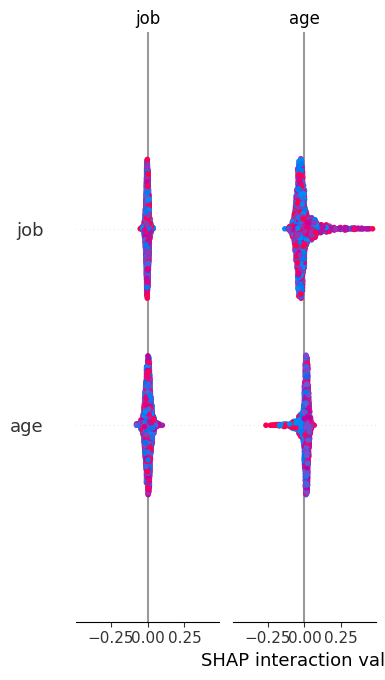

In [ ]:
import shap

explainer = shap.Explainer(rf, X_train)
shap_values = explainer(X_test)

shap.summary_plot(shap_values)

SHAP analysis shows which features most strongly influence subscription predictions.

Important features may include:
- balance
- age
- duration
- contact type

# Conclusion

The Random Forest model performed well in predicting term deposit subscriptions.

Key insights:
- Customer demographics and financial information influence subscription behavior
- SHAP improved model interpretability by explaining feature importance

This task strengthened understanding of classification modeling and explainable AI.